# Resolución técnica de la consigna — Series temporales BodegaAI

Este notebook organiza el análisis requerido por el Trabajo Práctico N.º 1 de Análisis de Series Temporales con un registro académico y reproducible. El caso de estudio se concentra en tráfico productivo de BodegaAI medido a frecuencia horaria.

Fuentes de tráfico productivo analizadas:

- `data/alb-prod-requests-2026-07.csv`: requests totales del Application Load Balancer durante julio de 2026.
- `data/bodegaai-production-pos-api-request-count-per-target-last-30-days-hourly.csv`: requests por target del POS API durante los últimos 30 días disponibles.

El flujo de trabajo presenta la preparación de datos, análisis de estacionariedad, identificación de dependencia temporal, estimación SARIMA, evaluación predictiva, diagnóstico de residuos, pronóstico y modelado VAR sobre el período común de observación.

## Guía de lectura según la consigna del PDF

| Bloque del PDF | Resolución en este notebook |
|---|---|
| Problemática analítica y elección de series | Se estudia el comportamiento horario del tráfico productivo de BodegaAI y se justifica la elección de métricas de requests. |
| Series originales y diferenciación | Se grafican niveles y transformaciones `diff(1)`, `diff(24)` y `diff(24).diff(1)`. |
| FAS, FAC y FACP | Se presentan conjuntamente para evaluar dependencia temporal y estacionalidad diaria. |
| Raíces unitarias | Se aplican ADF y KPSS como pruebas complementarias. |
| SARIMA | Se comparan órdenes con estacionalidad diaria `s = 24`. |
| Training/testing y métricas | Se reservan 48 horas como test y se calculan MAE, RMSE y MAPE. |
| Diagnóstico | Se inspeccionan residuos, FAC de residuos y Ljung-Box. |
| Pronóstico | Se proyectan 48 horas para cada serie. |
| VAR, impulso-respuesta y causalidad | Se usa el período temporal común y series transformadas para VAR, IRF y Granger. |
| Informe final | Este notebook funciona como soporte técnico; el informe PDF debe sintetizar resultados, marco teórico, conclusiones y referencias APA. |

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from matplotlib.ticker import FuncFormatter, ScalarFormatter
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, acovf, adfuller, kpss, grangercausalitytests
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.api import VAR

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


def format_es_number(value, decimals=2):
    if pd.isna(value):
        return ""
    formatted = f"{value:,.{decimals}f}"
    return formatted.replace(",", "_").replace(".", ",").replace("_", ".")


def format_es_count(value):
    return format_es_number(value, decimals=0)

pd.set_option("display.float_format", format_es_number)

COUNT_FORMATTER = FuncFormatter(lambda x, pos: format_es_count(x))

def format_count_axis(ax):
    ax.yaxis.set_major_formatter(COUNT_FORMATTER)
    return ax


def format_datetime_axis(ax):
    locator = mdates.AutoDateLocator(minticks=4, maxticks=7)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax.tick_params(axis="x", labelrotation=30)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
    return ax


def clean_count_table(df):
    return df.copy().style.format(precision=2, thousands=".", decimal=",")


## 1. Carga y preparación de datos

Las series se tratan con frecuencia horaria. Cada archivo se ordena por `period_start_utc`, se indexa temporalmente y se reindexa a una grilla horaria completa. Este procedimiento permite detectar huecos temporales y evita que los modelos trabajen sobre un calendario implícito incorrecto.

Los conteos se muestran con formato numérico español: punto como separador de miles y coma como separador decimal.

In [2]:
ALB_PATH = "data/alb-prod-requests-2026-07.csv"
POS_PATH = "data/bodegaai-production-pos-api-request-count-per-target-last-30-days-hourly.csv"


def load_hourly_series(path, value_col, name):
    df = pd.read_csv(path)
    df["period_start_utc"] = pd.to_datetime(df["period_start_utc"], utc=True)
    series = (
        df.sort_values("period_start_utc")
          .set_index("period_start_utc")[value_col]
          .astype(float)
          .rename(name)
    )
    full_index = pd.date_range(series.index.min(), series.index.max(), freq="h", tz="UTC")
    series = series.reindex(full_index).interpolate("time")
    series.index.name = "fecha_hora_utc"
    return series

alb = load_hourly_series(ALB_PATH, "requests", "requests_alb")
pos = load_hourly_series(POS_PATH, "value", "requests_pos_api")

summary = pd.DataFrame({
    "serie": ["ALB total", "POS API por target"],
    "inicio": [alb.index.min(), pos.index.min()],
    "fin": [alb.index.max(), pos.index.max()],
    "observaciones": [len(alb), len(pos)],
    "faltantes": [int(alb.isna().sum()), int(pos.isna().sum())],
    "mínimo": [alb.min(), pos.min()],
    "media": [alb.mean(), pos.mean()],
    "máximo": [alb.max(), pos.max()],
})
clean_count_table(summary)


,serie,inicio,fin,observaciones,faltantes,mínimo,media,máximo
0,ALB total,2026-07-01 00:00:00+00:00,2026-07-31 23:00:00+00:00,744,0,"883.045,00","2.114.963,32","2.536.631,00"
1,POS API por target,2026-07-18 23:00:00+00:00,2026-08-17 22:00:00+00:00,720,0,"318.307,50","829.949,69","924.146,50"


los dos archivos quedan convertidos en series horarias regulares, sin faltantes luego de reindexar. Como los rangos temporales no son idénticos, el modelado univariado puede usar cada historia completa, mientras que el análisis conjunto debe limitarse al período común.


## 2. Series originales y necesidad de diferenciación

Una serie estacionaria mantiene media, varianza y estructura de autocorrelación relativamente estables. En series horarias de tráfico productivo suele observarse estacionalidad diaria, es decir, patrones que se repiten cada 24 observaciones.

La inspección visual de los niveles permite evaluar tendencia local, cambios de escala y ciclos recurrentes. Si el componente diario domina la dinámica, la diferenciación estacional `y_t - y_{t-24}` resulta una transformación candidata. Si aún persisten cambios locales, puede complementarse con una diferencia regular `y_t - y_{t-1}`.

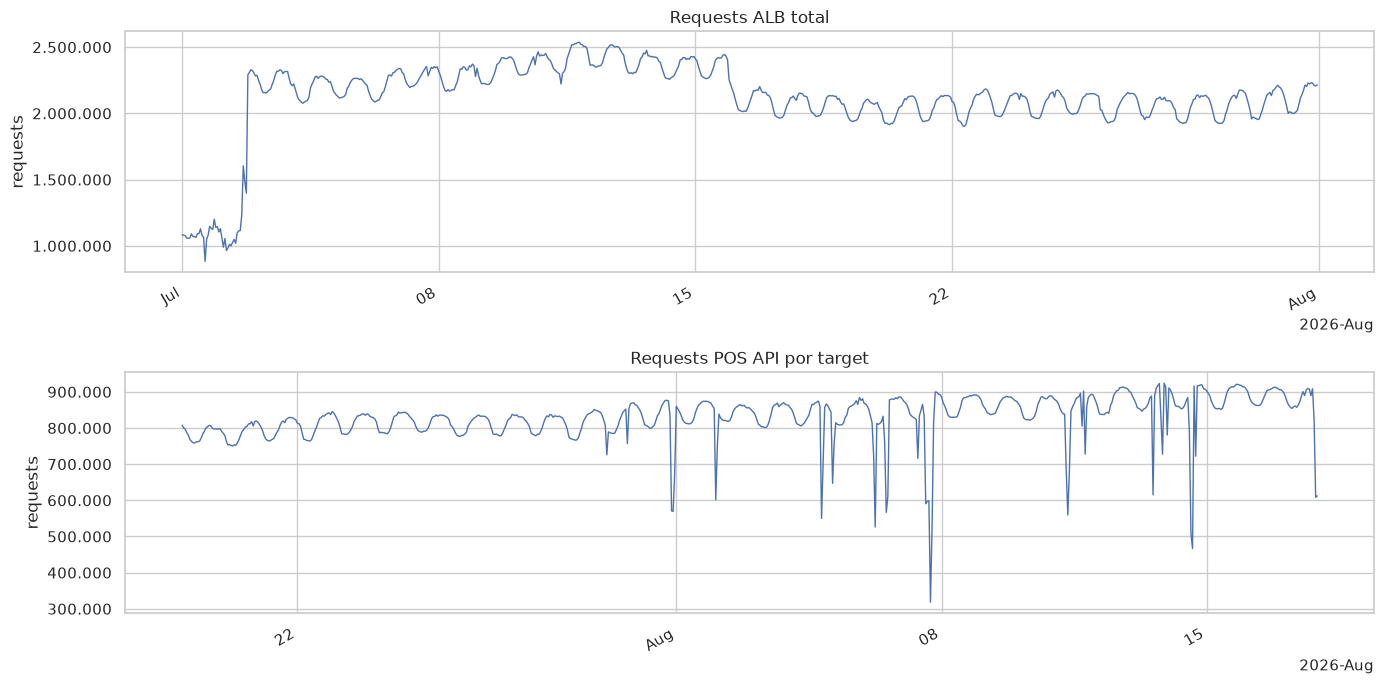

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
for ax, series, title in [
    (axes[0], alb, "Requests ALB total"),
    (axes[1], pos, "Requests POS API por target"),
]:
    ax.plot(series.index, series.values, linewidth=1)
    ax.set_title(title)
    ax.set_ylabel("requests")
    format_count_axis(ax)
    format_datetime_axis(ax)
plt.tight_layout()
plt.show()


ambas series muestran un patrón horario compatible con estacionalidad diaria. ALB presenta un cambio de nivel al inicio de julio y luego ciclos regulares; POS API conserva un nivel más estable, pero con caídas puntuales fuertes. Esto justifica evaluar transformaciones estacionales antes de ajustar modelos.


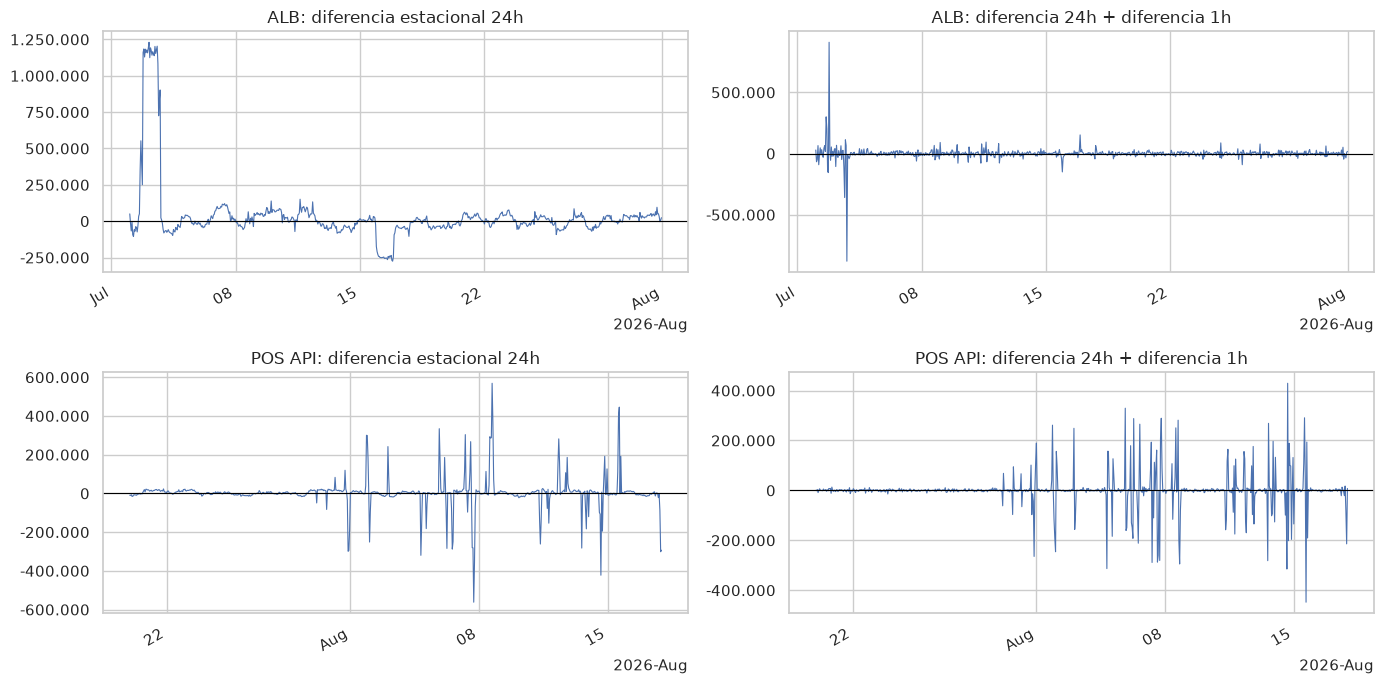

In [4]:
def transformed_versions(series):
    return pd.DataFrame({
        "original": series,
        "diff_1": series.diff(1),
        "diff_24": series.diff(24),
        "diff_1_y_24": series.diff(24).diff(1),
    }).dropna()

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=False)
for row, (series, title) in enumerate([(alb, "ALB"), (pos, "POS API")]):
    transformed = transformed_versions(series)
    axes[row, 0].plot(transformed.index, transformed["diff_24"], linewidth=0.8)
    axes[row, 0].set_title(f"{title}: diferencia estacional 24h")
    axes[row, 1].plot(transformed.index, transformed["diff_1_y_24"], linewidth=0.8)
    axes[row, 1].set_title(f"{title}: diferencia 24h + diferencia 1h")
    for ax in axes[row]:
        ax.axhline(0, color="black", linewidth=0.8)
        format_count_axis(ax)
        format_datetime_axis(ax)
plt.tight_layout()
plt.show()


la diferencia estacional de 24 horas reduce buena parte del ciclo diario. En ALB todavía se observan efectos del cambio de régimen inicial; en POS API permanecen shocks aislados asociados a caídas abruptas. La doble diferencia estabiliza más la media, pero también amplifica movimientos locales, por lo que debe usarse con criterio y no de forma automática.


## 3. FAS, FAC y FACP

- **FAS**: función de autocovarianza muestral. Mide dependencia en unidades originales.
- **FAC / ACF**: autocorrelación. Normaliza la autocovarianza entre -1 y 1.
- **FACP / PACF**: autocorrelación parcial. Mide la relación con un rezago descontando los rezagos intermedios.

Si aparecen picos en los rezagos 24, 48 o 72, hay evidencia visual de estacionalidad diaria. Si la FAC cae lentamente, la serie probablemente necesita diferenciación.


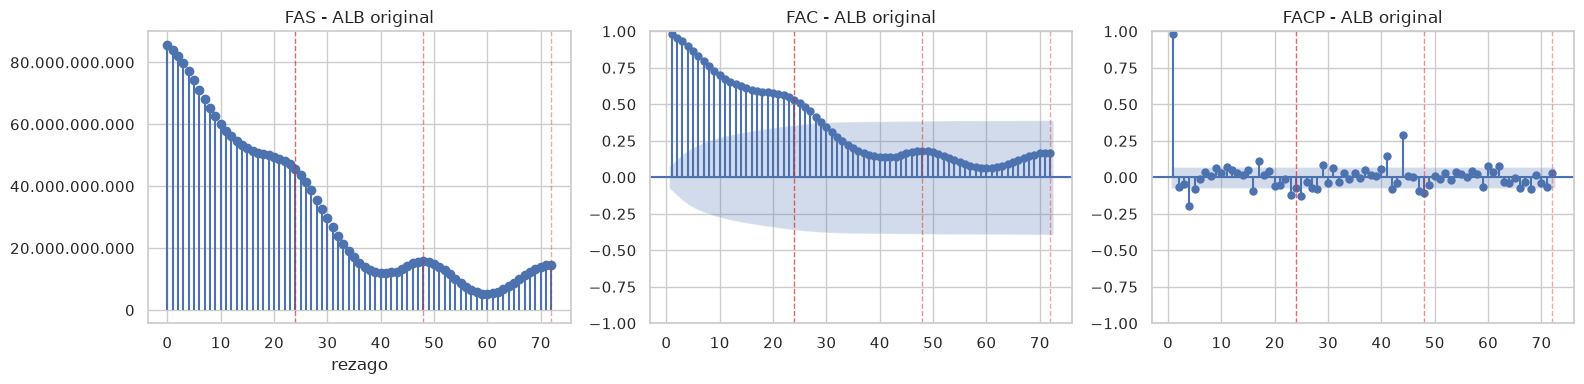

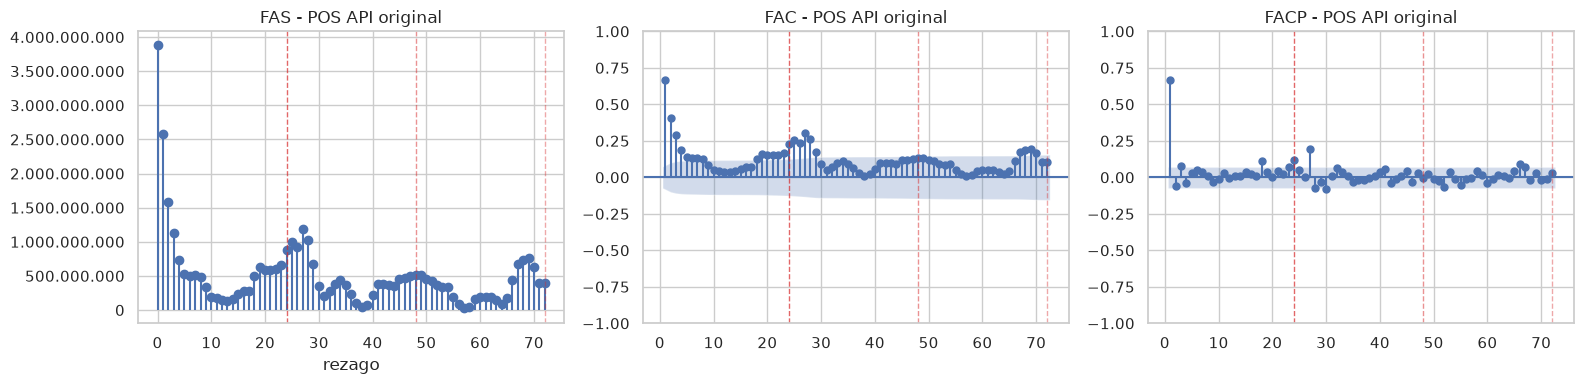

In [5]:
def plot_fas_fac_facp(series, title, lags=72):
    clean = series.dropna()
    fas_values = acovf(clean, fft=True, nlag=lags)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].stem(range(len(fas_values)), fas_values, basefmt=" ")
    axes[0].set_title(f"FAS - {title}")
    axes[0].set_xlabel("rezago")
    format_count_axis(axes[0])

    plot_acf(clean, lags=lags, ax=axes[1], zero=False)
    axes[1].set_title(f"FAC - {title}")

    plot_pacf(clean, lags=lags, ax=axes[2], zero=False, method="ywm")
    axes[2].set_title(f"FACP - {title}")

    for ax in axes:
        ax.axvline(24, color="tab:red", linestyle="--", linewidth=1, alpha=0.7)
        ax.axvline(48, color="tab:red", linestyle="--", linewidth=1, alpha=0.5)
        ax.axvline(72, color="tab:red", linestyle="--", linewidth=1, alpha=0.4)
    plt.tight_layout()
    plt.show()

plot_fas_fac_facp(alb, "ALB original")
plot_fas_fac_facp(pos, "POS API original")


la FAC evidencia dependencia temporal persistente y señales alrededor de rezagos diarios. La FACP ayuda a limitar órdenes autorregresivos simples, pero la estructura dominante sigue siendo estacional. Por eso, los modelos candidatos deben incluir `s = 24`.


## 4. Pruebas de raíces unitarias

Se aplican dos pruebas complementarias:

- **ADF**: la hipótesis nula sostiene que la serie posee raíz unitaria, por lo tanto no es estacionaria.
- **KPSS**: la hipótesis nula sostiene que la serie es estacionaria alrededor de una constante o tendencia.

La lectura conjunta evita una decisión mecánica. Cuando ADF no rechaza y KPSS rechaza, la evidencia favorece no estacionariedad. Cuando, luego de diferenciar, ADF rechaza y KPSS no rechaza, la transformación puede considerarse razonable para modelado.

In [6]:
def unit_root_tests(series, name):
    rows = []
    versions = {
        "original": series.dropna(),
        "diff_1": series.diff(1).dropna(),
        "diff_24": series.diff(24).dropna(),
        "diff_1_y_24": series.diff(24).diff(1).dropna(),
    }
    for version_name, values in versions.items():
        adf_stat, adf_p, _, _, _, _ = adfuller(values, autolag="AIC")
        try:
            kpss_stat, kpss_p, _, _ = kpss(values, regression="c", nlags="auto")
        except Exception:
            kpss_stat, kpss_p = np.nan, np.nan
        rows.append({
            "serie": name,
            "versión": version_name,
            "ADF estadístico": adf_stat,
            "ADF p-valor": adf_p,
            "KPSS estadístico": kpss_stat,
            "KPSS p-valor": kpss_p,
        })
    return pd.DataFrame(rows)

unit_tests = pd.concat([
    unit_root_tests(alb, "ALB"),
    unit_root_tests(pos, "POS API"),
], ignore_index=True)
clean_count_table(unit_tests)


,serie,versión,ADF estadístico,ADF p-valor,KPSS estadístico,KPSS p-valor
0,ALB,original,"-4,53","0,00","0,41","0,07"
1,ALB,diff_1,"-9,70","0,00","0,17","0,10"
2,ALB,diff_24,"-7,56","0,00","0,54","0,03"
3,ALB,diff_1_y_24,"-10,10","0,00","0,02","0,10"
4,POS API,original,"-9,55","0,00","2,33","0,01"
5,POS API,diff_1,"-10,82","0,00","0,13","0,10"
6,POS API,diff_24,"-6,21","0,00","0,02","0,10"
7,POS API,diff_1_y_24,"-10,43","0,00","0,24","0,10"


los tests confirman que la decisión no debe ser mecánica. ALB en niveles ya muestra evidencia compatible con estacionariedad al 5%, aunque mantiene estructura diaria clara; POS API presenta evidencia mixta en niveles y mejora con transformaciones. La estrategia correcta es combinar pruebas, gráficos y diagnóstico posterior del modelo.


## 5. Selección de modelos SARIMA

Los datos son horarios y presentan indicios de periodicidad diaria; por ese motivo se evalúan modelos SARIMA con período estacional `s = 24`. La grilla se mantiene deliberadamente acotada para reducir sobreajuste y costo computacional, dado que cada serie contiene aproximadamente un mes de observaciones.

La selección considera criterios de información en entrenamiento y desempeño fuera de muestra. Cuando ambas señales no coinciden, se prioriza el desempeño en test porque la consigna exige validar capacidad predictiva sobre una ventana reservada, no solo ajuste dentro de muestra.


In [7]:
def train_test_split_series(series, test_size=48):
    train = series.iloc[:-test_size]
    test = series.iloc[-test_size:]
    return train, test


def manual_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    errors = y_true - y_pred
    mae = np.mean(np.abs(errors))
    rmse = np.sqrt(np.mean(errors ** 2))
    denom = np.where(y_true == 0, np.nan, y_true)
    mape = np.nanmean(np.abs(errors / denom)) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE_%": mape}

# Grilla chica: combina diferencia regular/estacional con pocos órdenes ARMA.
SARIMA_CANDIDATES = [
    {"order": (1, 0, 1), "seasonal_order": (1, 0, 1, 24)},
    {"order": (1, 1, 1), "seasonal_order": (1, 0, 1, 24)},
    {"order": (1, 0, 1), "seasonal_order": (1, 1, 1, 24)},
    {"order": (1, 1, 1), "seasonal_order": (1, 1, 1, 24)},
]


def fit_sarima_candidates(series, name, test_size=48):
    train, test = train_test_split_series(series, test_size=test_size)
    rows = []
    fitted_models = {}
    for candidate in SARIMA_CANDIDATES:
        order = candidate["order"]
        seasonal_order = candidate["seasonal_order"]
        label = f"SARIMA{order}x{seasonal_order}"
        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            result = model.fit(disp=False, maxiter=80)
            forecast = result.get_forecast(steps=len(test)).predicted_mean
            metrics = manual_metrics(test.values, forecast.values)
            rows.append({
                "serie": name,
                "modelo": label,
                "AIC": result.aic,
                "BIC": result.bic,
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "MAPE_%": metrics["MAPE_%"],
            })
            fitted_models[label] = result
        except Exception as exc:
            rows.append({
                "serie": name,
                "modelo": label,
                "AIC": np.nan,
                "BIC": np.nan,
                "MAE": np.nan,
                "RMSE": np.nan,
                "MAPE_%": np.nan,
            })
    comparison = pd.DataFrame(rows).sort_values(["MAPE_%", "AIC"], na_position="last")
    best_label = comparison.iloc[0]["modelo"]
    return comparison, fitted_models[best_label], best_label, train, test

alb_comparison, alb_best, alb_best_label, alb_train, alb_test = fit_sarima_candidates(alb, "ALB")
pos_comparison, pos_best, pos_best_label, pos_train, pos_test = fit_sarima_candidates(pos, "POS API")

sarima_comparison = pd.concat([alb_comparison, pos_comparison], ignore_index=True)
clean_count_table(sarima_comparison)


,serie,modelo,AIC,BIC,MAE,RMSE,MAPE_%
0,ALB,"SARIMA(1, 1, 1)x(1, 1, 1, 24)","15.491,11","15.513,46","16.662,34","20.309,65","0,79"
1,ALB,"SARIMA(1, 0, 1)x(1, 1, 1, 24)","15.527,20","15.549,55","26.776,12","32.527,51","1,26"
2,ALB,"SARIMA(1, 0, 1)x(1, 0, 1, 24)","16.264,80","16.287,34","74.058,90","93.572,86","3,64"
3,ALB,"SARIMA(1, 1, 1)x(1, 0, 1, 24)","16.229,29","16.251,82","76.283,64","95.622,16","3,74"
4,POS API,"SARIMA(1, 1, 1)x(1, 0, 1, 24)","15.737,10","15.759,45","29.640,50","58.453,68","3,90"
5,POS API,"SARIMA(1, 0, 1)x(1, 0, 1, 24)","15.860,56","15.882,91","30.840,10","59.890,01","4,08"
6,POS API,"SARIMA(1, 0, 1)x(1, 1, 1, 24)","15.381,30","15.403,47","39.594,21","82.710,35","5,09"
7,POS API,"SARIMA(1, 1, 1)x(1, 1, 1, 24)","15.467,63","15.489,79","45.860,88","82.189,96","5,91"


dentro de la grilla evaluada, ALB queda mejor representada por `SARIMA(1, 1, 1)x(1, 1, 1, 24)` y POS API por `SARIMA(1, 1, 1)x(1, 0, 1, 24)`. La selección prioriza desempeño fuera de muestra cuando entra en tensión con AIC/BIC, porque el objetivo operativo del bloque es pronosticar sobre una ventana reservada.


In [8]:
def sarima_parameter_table(result, serie, modelo):
    conf = result.conf_int()
    table = pd.DataFrame({
        "serie": serie,
        "modelo": modelo,
        "parámetro": result.params.index,
        "coeficiente": result.params.values,
        "error_std": result.bse.values,
        "z": result.tvalues.values,
        "p_valor": result.pvalues.values,
        "ic_95_inf": conf.iloc[:, 0].values,
        "ic_95_sup": conf.iloc[:, 1].values,
    })
    return table

sarima_parameters = pd.concat([
    sarima_parameter_table(alb_best, "ALB", alb_best_label),
    sarima_parameter_table(pos_best, "POS API", pos_best_label),
], ignore_index=True)

sarima_selected = pd.DataFrame([
    {"serie": "ALB", "modelo_seleccionado": alb_best_label, "AIC": alb_best.aic, "BIC": alb_best.bic},
    {"serie": "POS API", "modelo_seleccionado": pos_best_label, "AIC": pos_best.aic, "BIC": pos_best.bic},
])

display(clean_count_table(sarima_selected))
display(clean_count_table(sarima_parameters))

,serie,modelo_seleccionado,AIC,BIC
0,ALB,"SARIMA(1, 1, 1)x(1, 1, 1, 24)","15.491,11","15.513,46"
1,POS API,"SARIMA(1, 1, 1)x(1, 0, 1, 24)","15.737,10","15.759,45"


,serie,modelo,parámetro,coeficiente,error_std,z,p_valor,ic_95_inf,ic_95_sup
0,ALB,"SARIMA(1, 1, 1)x(1, 1, 1, 24)",ar.L1,"-0,08","2,37","-0,04","0,97","-4,73","4,57"
1,ALB,"SARIMA(1, 1, 1)x(1, 1, 1, 24)",ma.L1,"0,01","2,33","0,01","1,00","-4,56","4,58"
2,ALB,"SARIMA(1, 1, 1)x(1, 1, 1, 24)",ar.S.L24,"-0,15","0,02","-7,28","0,00","-0,19","-0,11"
3,ALB,"SARIMA(1, 1, 1)x(1, 1, 1, 24)",ma.S.L24,"-0,52","0,02","-28,85","0,00","-0,56","-0,49"
4,ALB,"SARIMA(1, 1, 1)x(1, 1, 1, 24)",sigma2,"3.314.618.119,29","0,00","197.007.419.777.018.400,00","0,00","3.314.618.119,29","3.314.618.119,29"
5,POS API,"SARIMA(1, 1, 1)x(1, 0, 1, 24)",ar.L1,"0,57","0,02","27,91","0,00","0,53","0,61"
6,POS API,"SARIMA(1, 1, 1)x(1, 0, 1, 24)",ma.L1,"-0,97","0,01","-74,02","0,00","-0,99","-0,94"
7,POS API,"SARIMA(1, 1, 1)x(1, 0, 1, 24)",ar.S.L24,"-0,22","0,18","-1,25","0,21","-0,57","0,13"
8,POS API,"SARIMA(1, 1, 1)x(1, 0, 1, 24)",ma.S.L24,"0,27","0,18","1,53","0,13","-0,08","0,61"
9,POS API,"SARIMA(1, 1, 1)x(1, 0, 1, 24)",sigma2,"2.525.534.011,33","0,00","22.702.414.045.126.615.040,00","0,00","2.525.534.011,33","2.525.534.011,33"


los parámetros significativos se concentran sobre todo en la dinámica estacional y de corto plazo. No todos los coeficientes individuales son relevantes al 5%, por lo que la elección del modelo no se apoya en un único parámetro, sino en el balance entre desempeño predictivo, parsimonia y diagnóstico.


## 6. Evaluación train/test y métricas

Las últimas 48 horas se reservan como conjunto de prueba. El horizonte es coherente con la frecuencia horaria y evita extrapolar demasiado lejos con una muestra histórica corta.

Métricas empleadas:

- **MAE**: error absoluto medio.
- **RMSE**: error cuadrático medio con mayor penalización a errores grandes.
- **MAPE**: error porcentual medio; resulta interpretable cuando los valores reales no se aproximan a cero.

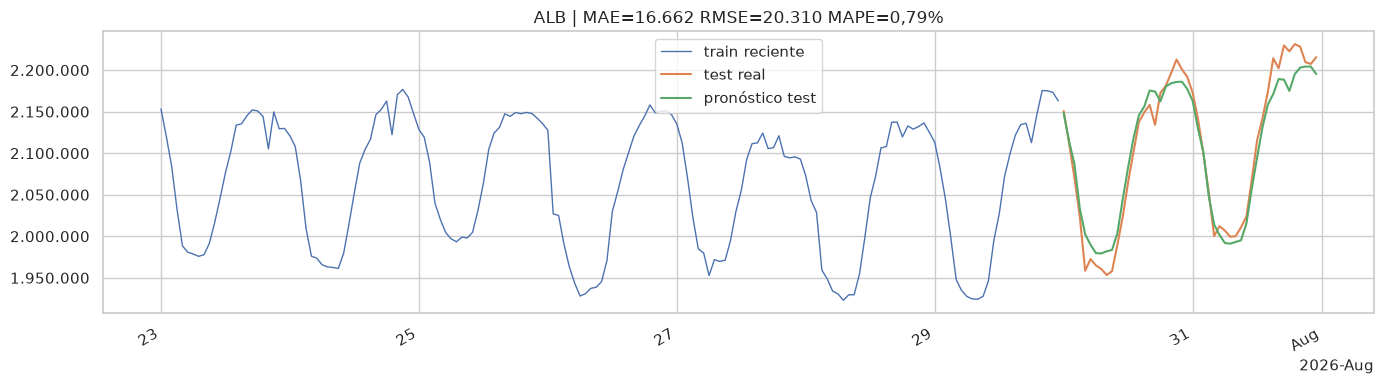

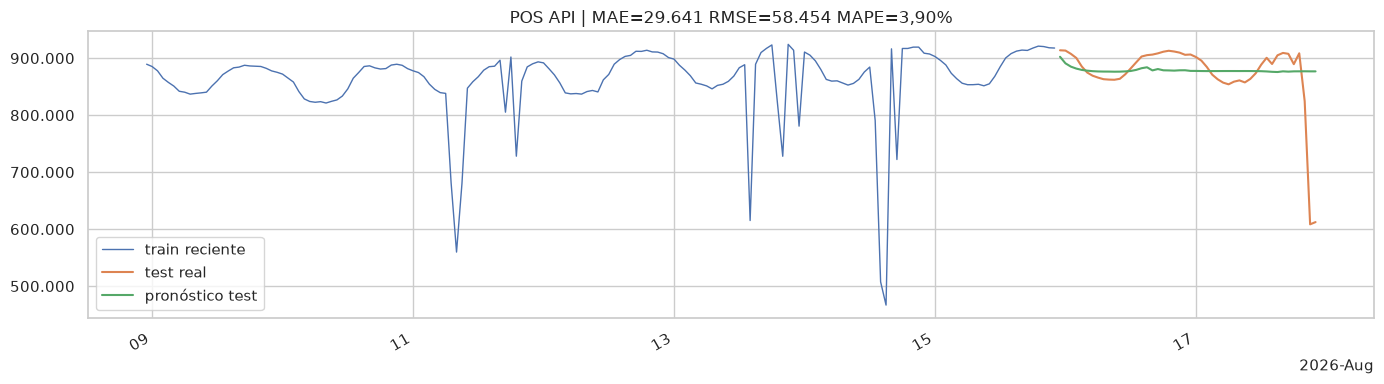

,serie,MAE,RMSE,MAPE_%
0,ALB,"16.662,34","20.309,65","0,79"
1,POS API,"29.640,50","58.453,68","3,90"


In [9]:
def plot_test_forecast(train, test, result, title):
    pred = result.get_forecast(steps=len(test)).predicted_mean
    metrics = manual_metrics(test.values, pred.values)
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(train.index[-7*24:], train.iloc[-7*24:], label="train reciente", linewidth=1)
    ax.plot(test.index, test, label="test real", linewidth=1.5)
    ax.plot(test.index, pred, label="pronóstico test", linewidth=1.5)
    ax.set_title(f"{title} | MAE={format_es_count(metrics['MAE'])} RMSE={format_es_count(metrics['RMSE'])} MAPE={format_es_number(metrics['MAPE_%'])}%")
    ax.legend()
    format_count_axis(ax)
    format_datetime_axis(ax)
    plt.tight_layout()
    plt.show()
    return metrics

alb_metrics = plot_test_forecast(alb_train, alb_test, alb_best, "ALB")
pos_metrics = plot_test_forecast(pos_train, pos_test, pos_best, "POS API")
clean_count_table(pd.DataFrame([{"serie": "ALB", **alb_metrics}, {"serie": "POS API", **pos_metrics}]))


el test de 48 horas muestra pronósticos útiles para ambas series. ALB obtiene el mejor ajuste relativo, con MAPE cercano a `0,79%`; POS API mantiene un error mayor, cercano a `3,90%`, razonable considerando sus caídas abruptas recientes.


## 7. Comparación con modelos alternativos

La comparación incorpora tanto criterios de información como desempeño predictivo en test. En series con patrón diario, los modelos con componente estacional suelen capturar estructura que un ARIMA no estacional trataría como persistencia residual.

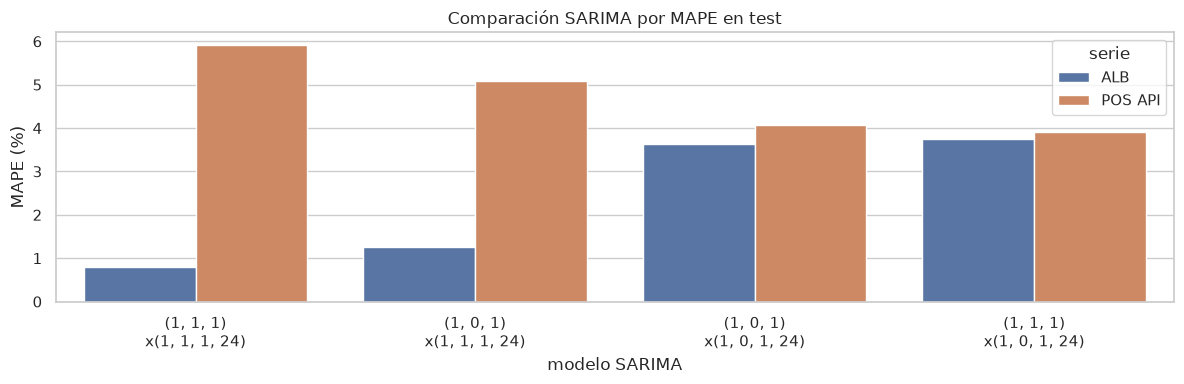

In [10]:
comparison_plot = sarima_comparison.copy()
comparison_plot["modelo_corto"] = (
    comparison_plot["modelo"]
    .str.replace("SARIMA", "", regex=False)
    .str.replace("x", "\nx", regex=False)
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.barplot(data=comparison_plot, x="modelo_corto", y="MAPE_%", hue="serie", ax=ax)
ax.set_title("Comparación SARIMA por MAPE en test")
ax.set_xlabel("modelo SARIMA")
ax.set_ylabel("MAPE (%)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


los modelos con estacionalidad diaria dominan la comparación predictiva. En POS API, el modelo elegido no es el de menor AIC/BIC, pero sí el de menor MAPE en test; por eso la decisión queda alineada con validación fuera de muestra y no solo con ajuste interno.


## 8. Diagnóstico de residuos

Un buen modelo debería dejar residuos aproximadamente centrados en cero, sin autocorrelación fuerte. Para eso revisamos:

- Serie temporal de residuos.
- Histograma.
- FAC de residuos.
- Test de Ljung-Box: hipótesis nula = no hay autocorrelación conjunta hasta el rezago evaluado.


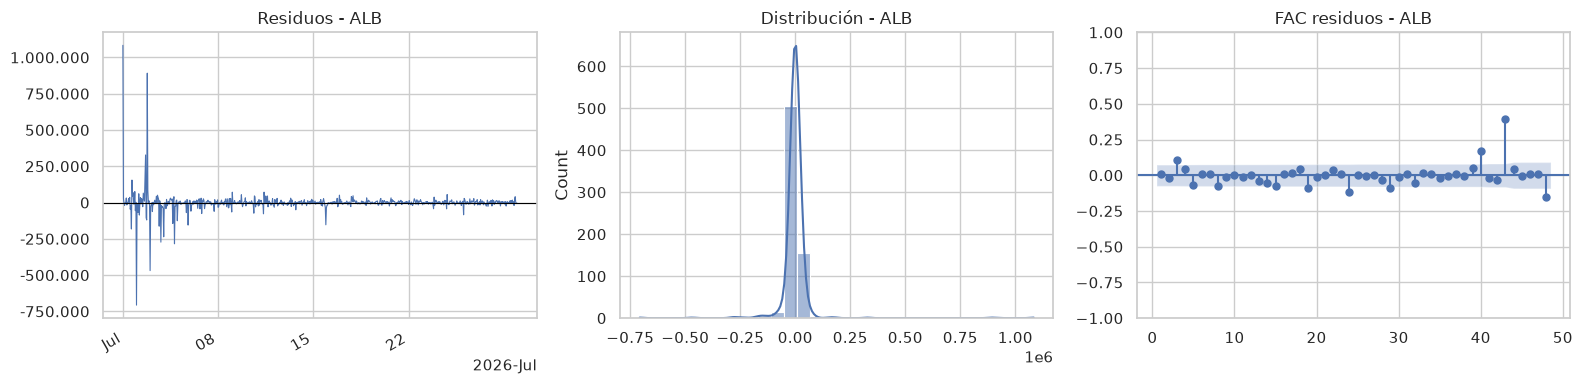

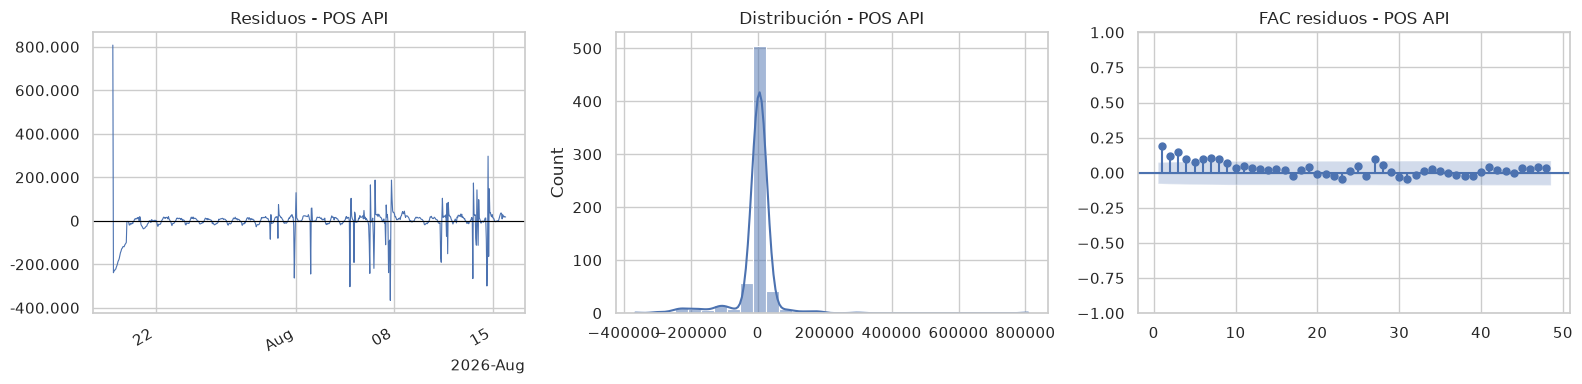

,rezago,Ljung-Box,p-valor,serie
0,12,"17,40","0,14",ALB
1,24,"43,64","0,01",ALB
2,48,"212,49","0,00",ALB
3,12,"86,58","0,00",POS API
4,24,"92,07","0,00",POS API
5,48,"112,38","0,00",POS API


In [11]:
def residual_diagnostics(result, title, lags=48):
    resid = pd.Series(result.resid).dropna()
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(resid.index, resid.values, linewidth=0.8)
    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].set_title(f"Residuos - {title}")
    format_count_axis(axes[0])
    format_datetime_axis(axes[0])

    sns.histplot(resid, bins=30, kde=True, ax=axes[1])
    axes[1].set_title(f"Distribución - {title}")
    format_count_axis(axes[1])

    plot_acf(resid, lags=lags, ax=axes[2], zero=False)
    axes[2].set_title(f"FAC residuos - {title}")
    plt.tight_layout()
    plt.show()

    lb = acorr_ljungbox(resid, lags=[12, 24, 48], return_df=True)
    return lb.reset_index().rename(columns={"index": "rezago", "lb_stat": "Ljung-Box", "lb_pvalue": "p-valor"})

alb_lb = residual_diagnostics(alb_best, "ALB")
pos_lb = residual_diagnostics(pos_best, "POS API")
clean_count_table(pd.concat([alb_lb.assign(serie="ALB"), pos_lb.assign(serie="POS API")], ignore_index=True))


los residuos aún conservan autocorrelación. ALB no rechaza Ljung-Box en rezago 12, pero sí en 24 y 48; POS API rechaza en todos los rezagos evaluados. Los SARIMA seleccionados son una base predictiva razonable, no modelos definitivos sin estructura remanente.


## 9. Pronóstico con el modelo seleccionado

Se pronostican 48 horas para cada serie. La ventana conserva una escala operativa razonable: cubre dos ciclos diarios completos y evita una extrapolación excesiva para una muestra de aproximadamente 30 días.

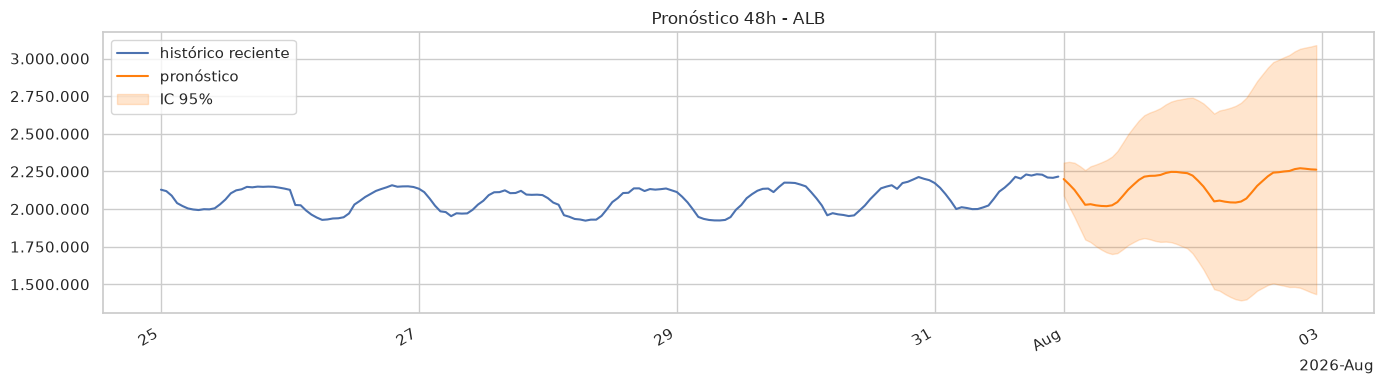

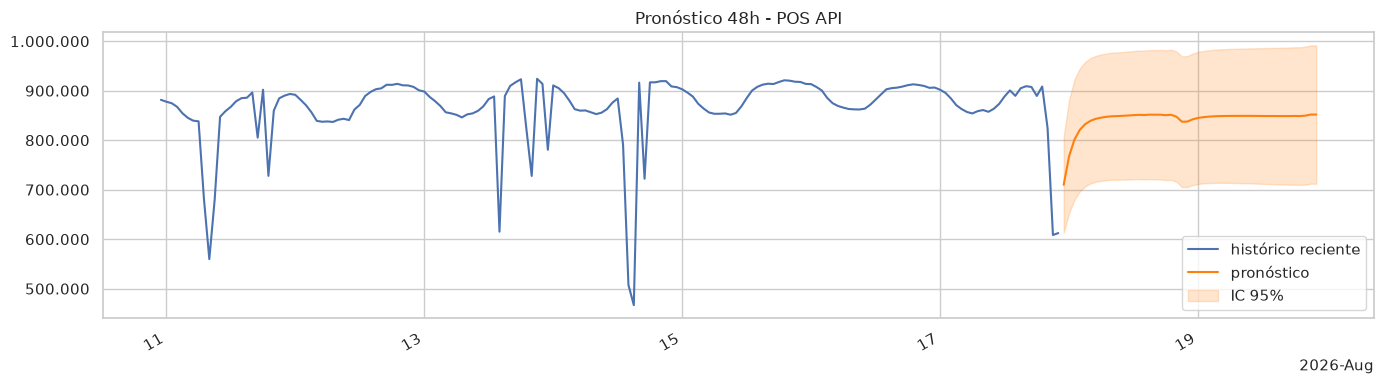

In [12]:
def refit_and_forecast(series, best_label, steps=48):
    candidate = None
    for item in SARIMA_CANDIDATES:
        label = f"SARIMA{item['order']}x{item['seasonal_order']}"
        if label == best_label:
            candidate = item
            break
    model = SARIMAX(
        series,
        order=candidate["order"],
        seasonal_order=candidate["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    result = model.fit(disp=False, maxiter=80)
    forecast = result.get_forecast(steps=steps)
    mean = forecast.predicted_mean
    interval = forecast.conf_int()
    return result, mean, interval

alb_final, alb_forecast, alb_interval = refit_and_forecast(alb, alb_best_label)
pos_final, pos_forecast, pos_interval = refit_and_forecast(pos, pos_best_label)


def plot_future_forecast(series, mean, interval, title):
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(series.index[-7*24:], series.iloc[-7*24:], label="histórico reciente")
    ax.plot(mean.index, mean, label="pronóstico", color="tab:orange")
    ax.fill_between(mean.index, interval.iloc[:, 0], interval.iloc[:, 1], color="tab:orange", alpha=0.2, label="IC 95%")
    ax.set_title(title)
    ax.legend()
    format_count_axis(ax)
    format_datetime_axis(ax)
    plt.tight_layout()
    plt.show()

plot_future_forecast(alb, alb_forecast, alb_interval, "Pronóstico 48h - ALB")
plot_future_forecast(pos, pos_forecast, pos_interval, "Pronóstico 48h - POS API")


el pronóstico a 48 horas mantiene la escala y el ciclo esperados, pero la incertidumbre crece rápidamente. Las bandas deben leerse como una advertencia: con una muestra de aproximadamente un mes, el horizonte es útil para planificación corta, no para inferencias de largo plazo.


## 10. VAR sobre series alineadas y transformadas

El modelo VAR exige que las variables compartan el mismo calendario. Dado que los archivos cubren rangos distintos, se utiliza únicamente la intersección temporal disponible.

Además, se aplica `log1p` y diferenciación estacional de 24 horas. Esta transformación estabiliza escala y centra el VAR en variaciones estacionales, no en niveles absolutos de requests.

Por esa razón, las métricas del VAR se reportan en la escala transformada. No se usa MAPE en este bloque: al trabajar con diferencias logarítmicas, los valores reales pueden quedar cerca de cero o cambiar de signo, y un porcentaje de error dejaría de tener una interpretación operativa clara.

La selección de rezagos se informa de forma transparente porque puede ser sensible en muestras cortas: AIC puede preferir una dinámica más larga que BIC/HQIC, aumentando el riesgo de sobreparametrización.


Rango ALB: 2026-07-01 00:00:00+00:00 a 2026-07-31 23:00:00+00:00
Rango POS API: 2026-07-18 23:00:00+00:00 a 2026-08-17 22:00:00+00:00
Rango común usado en VAR: 2026-07-18 23:00:00+00:00 a 2026-07-31 23:00:00+00:00
Observaciones VAR después de transformar: 289


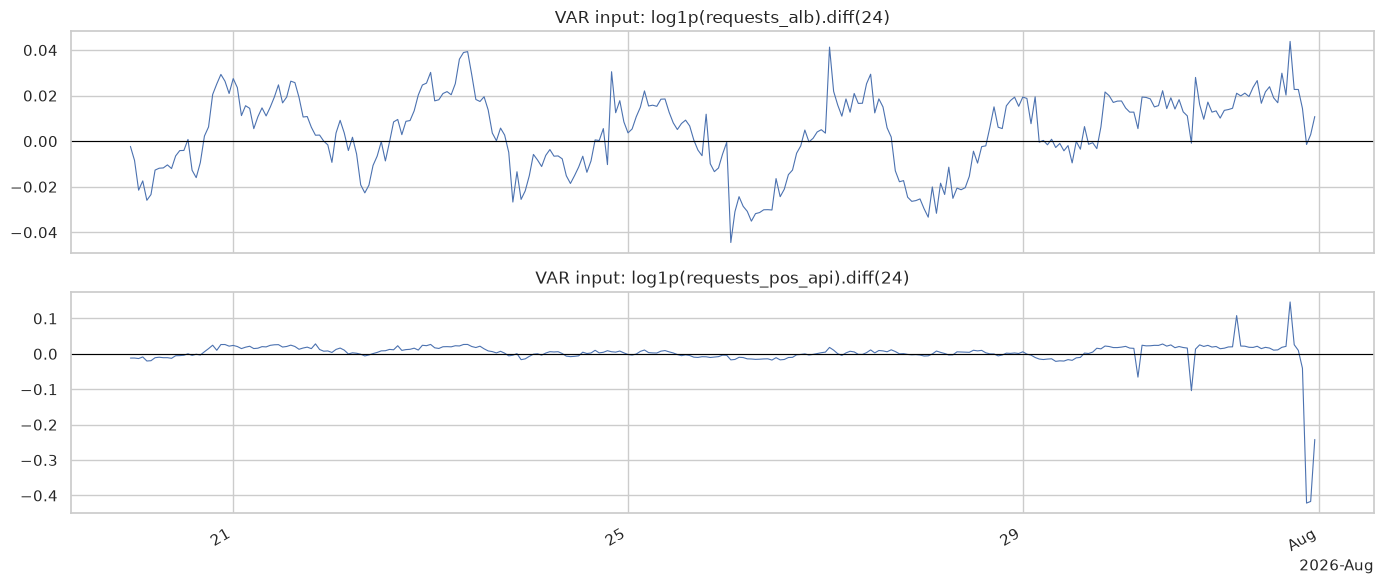

In [13]:
aligned = pd.concat([alb, pos], axis=1, join="inner").dropna()
aligned_log = np.log1p(aligned)
var_data = aligned_log.diff(24).dropna()

print("Rango ALB:", alb.index.min(), "a", alb.index.max())
print("Rango POS API:", pos.index.min(), "a", pos.index.max())
print("Rango común usado en VAR:", aligned.index.min(), "a", aligned.index.max())
print("Observaciones VAR después de transformar:", len(var_data))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, col in zip(axes, var_data.columns):
    ax.plot(var_data.index, var_data[col], linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"VAR input: log1p({col}).diff(24)")
    format_datetime_axis(ax)
plt.tight_layout()
plt.show()


el VAR queda limitado al tramo común entre ambas series. Luego de `log1p + diff(24)`, el modelo trabaja sobre variaciones estacionales y no sobre niveles absolutos; por eso sus resultados no son directamente comparables con las métricas SARIMA calculadas en requests.


In [14]:
var_train = var_data.iloc[:-48]
var_test = var_data.iloc[-48:]
var_model = VAR(var_train)
selection = var_model.select_order(maxlags=24)

selection_table = pd.DataFrame(selection.ics)
selection_table.index.name = "rezagos"
display(clean_count_table(selection_table.reset_index()))

selected_lag = selection.selected_orders.get("aic")
if selected_lag is None or selected_lag < 1:
    selected_lag = 1
selected_lag = int(min(selected_lag, 24))
print("Rezagos VAR seleccionados por AIC:", selected_lag)

var_result = var_model.fit(selected_lag)

var_params = var_result.params.reset_index().rename(columns={"index": "parámetro"})
var_pvalues = var_result.pvalues.reset_index().rename(columns={"index": "parámetro"})
var_params_long = var_params.melt(id_vars="parámetro", var_name="ecuación", value_name="coeficiente")
var_pvalues_long = var_pvalues.melt(id_vars="parámetro", var_name="ecuación", value_name="p_valor")
var_coefficients = var_params_long.merge(var_pvalues_long, on=["parámetro", "ecuación"])
display(clean_count_table(var_coefficients))

var_forecast_values = var_result.forecast(var_train.values[-selected_lag:], steps=len(var_test))
var_forecast = pd.DataFrame(var_forecast_values, index=var_test.index, columns=var_test.columns)

def transformed_scale_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    errors = y_true - y_pred
    return {
        "MAE": np.mean(np.abs(errors)),
        "RMSE": np.sqrt(np.mean(errors ** 2)),
    }

var_metrics = []
for col in var_test.columns:
    metrics = transformed_scale_metrics(var_test[col].values, var_forecast[col].values)
    var_metrics.append({
        "serie_transformada": col,
        **metrics,
        "escala": "log1p + diff(24)",
    })
clean_count_table(pd.DataFrame(var_metrics))


,rezagos,aic,bic,hqic,fpe
0,0,"-17,67","-17,64","-17,66","0,00"
1,1,"-20,48","-20,39","-20,44","0,00"
2,2,"-20,55","-20,40","-20,49","0,00"
3,3,"-20,53","-20,31","-20,44","0,00"
4,4,"-20,50","-20,22","-20,39","0,00"
5,5,"-20,50","-20,15","-20,36","0,00"
6,6,"-20,49","-20,08","-20,32","0,00"
7,7,"-20,50","-20,03","-20,31","0,00"
8,8,"-20,47","-19,94","-20,26","0,00"
9,9,"-20,45","-19,86","-20,22","0,00"


Rezagos VAR seleccionados por AIC: 24


,parámetro,ecuación,coeficiente,p_valor
0,const,requests_alb,"-0,00","0,09"
1,L1.requests_alb,requests_alb,"0,30","0,00"
2,L1.requests_pos_api,requests_alb,"0,62","0,00"
3,L2.requests_alb,requests_alb,"0,23","0,02"
4,L2.requests_pos_api,requests_alb,"-0,09","0,61"
5,L3.requests_alb,requests_alb,"0,09","0,33"
6,L3.requests_pos_api,requests_alb,"-0,11","0,48"
7,L4.requests_alb,requests_alb,"0,16","0,09"
8,L4.requests_pos_api,requests_alb,"-0,18","0,26"
9,L5.requests_alb,requests_alb,"-0,09","0,37"


,serie_transformada,MAE,RMSE,escala
0,requests_alb,"0,01","0,01",log1p + diff(24)
1,requests_pos_api,"0,04","0,10",log1p + diff(24)


AIC selecciona 24 rezagos, lo que captura un ciclo diario completo, pero puede ser sensible porque el período común transformado tiene pocas observaciones. Las métricas VAR se reportan en escala transformada y se omite MAPE porque las diferencias logarítmicas pueden acercarse a cero o cambiar de signo.


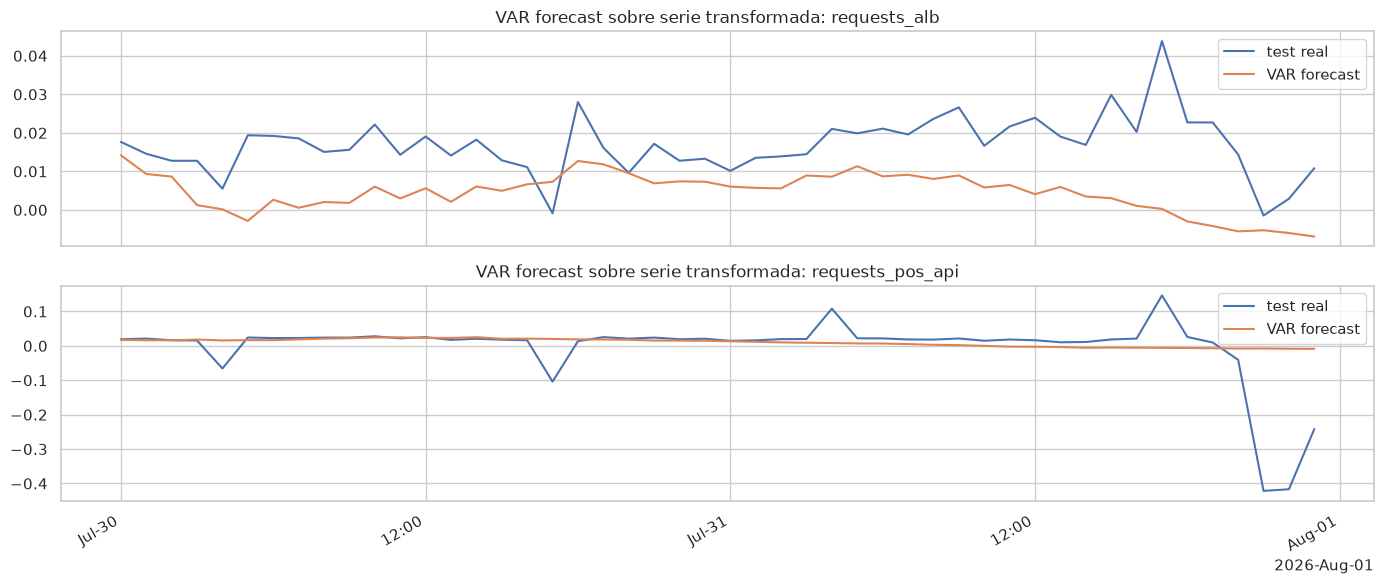

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, col in zip(axes, var_test.columns):
    ax.plot(var_test.index, var_test[col], label="test real", linewidth=1.5)
    ax.plot(var_forecast.index, var_forecast[col], label="VAR forecast", linewidth=1.5)
    ax.set_title(f"VAR forecast sobre serie transformada: {col}")
    ax.legend()
    format_datetime_axis(ax)
plt.tight_layout()
plt.show()


el forecast VAR sirve como lectura exploratoria de co-movimientos en el tramo compartido. Su desempeño debe interpretarse con cautela: no reemplaza los SARIMA univariados para pronóstico en niveles y depende fuertemente de la transformación aplicada.


## 11. Impulso-respuesta y causalidad de Granger

La función impulso-respuesta muestra cómo responde una variable del VAR ante un shock en otra variable. La causalidad de Granger no prueba causalidad económica real; prueba si los rezagos de una serie ayudan a predecir la otra, dado el modelo y la muestra disponible.


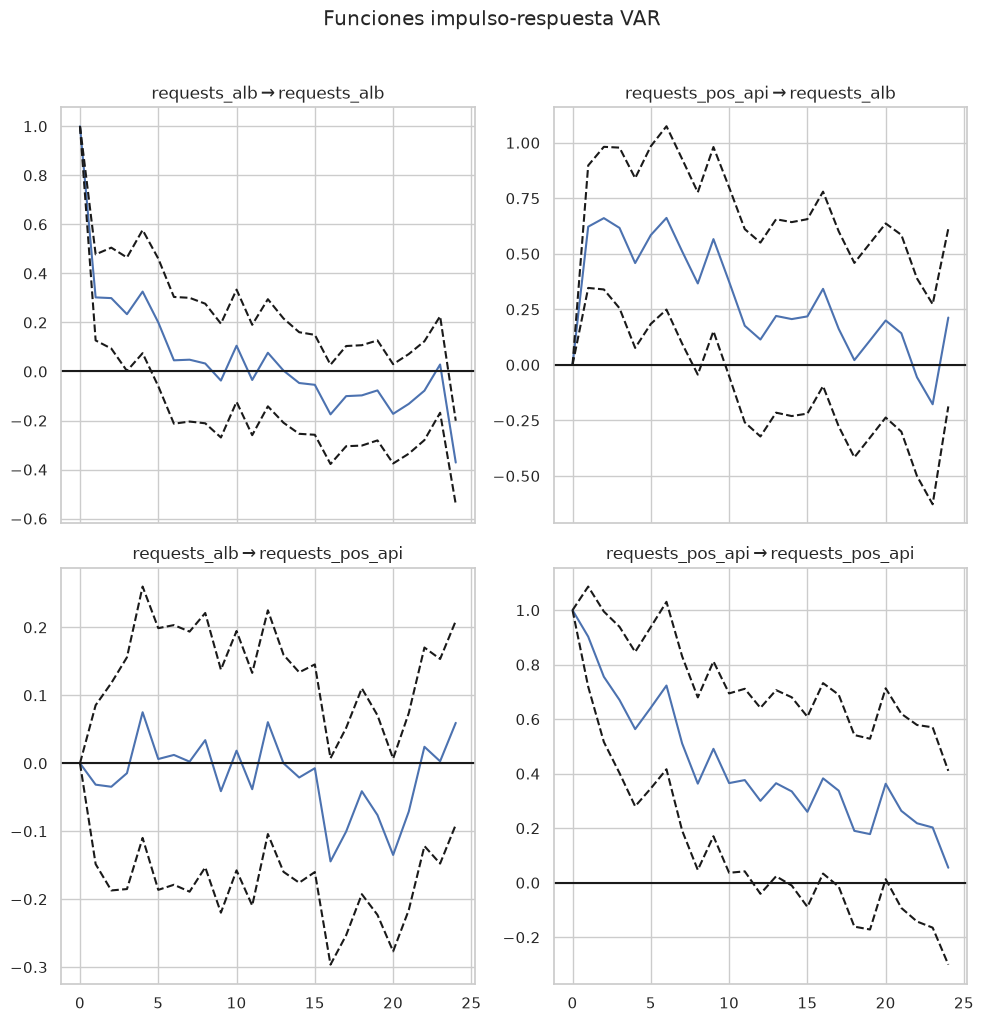

,prueba,variable_causada,variable_causante,estadístico_F,p_valor,decisión_5pct,rezagos
0,VAR ajustado,requests_alb,requests_pos_api,"2,22","0,00",rechaza H0,nan
1,VAR ajustado,requests_pos_api,requests_alb,"1,26","0,19",no rechaza H0,nan
2,Granger bivariada,requests_alb,requests_pos_api,"0,70","0,65",no rechaza H0,"6,00"
3,Granger bivariada,requests_alb,requests_pos_api,"0,58","0,86",no rechaza H0,"12,00"
4,Granger bivariada,requests_alb,requests_pos_api,"1,11","0,34",no rechaza H0,"24,00"
5,Granger bivariada,requests_pos_api,requests_alb,"1,10","0,36",no rechaza H0,"6,00"
6,Granger bivariada,requests_pos_api,requests_alb,"0,75","0,70",no rechaza H0,"12,00"
7,Granger bivariada,requests_pos_api,requests_alb,"0,68","0,87",no rechaza H0,"24,00"


In [16]:
irf = var_result.irf(24)
irf.plot(orth=False)
plt.suptitle("Funciones impulso-respuesta VAR", y=1.02)
plt.tight_layout()
plt.show()

causality_rows = []
for caused in var_data.columns:
    causing = [col for col in var_data.columns if col != caused]
    test = var_result.test_causality(caused=caused, causing=causing, kind="f")
    causality_rows.append({
        "prueba": "VAR ajustado",
        "variable_causada": caused,
        "variable_causante": ", ".join(causing),
        "estadístico_F": test.test_statistic,
        "p_valor": test.pvalue,
        "decisión_5pct": "rechaza H0" if test.pvalue < 0.05 else "no rechaza H0",
    })

def granger_table(data, caused, causing, lags=(6, 12, 24)):
    # statsmodels espera primero la variable causada y luego la causante.
    result = grangercausalitytests(data[[caused, causing]], maxlag=list(lags), verbose=False)
    rows = []
    for lag in lags:
        f_stat, p_value, _, _ = result[lag][0]["ssr_ftest"]
        rows.append({
            "prueba": "Granger bivariada",
            "variable_causada": caused,
            "variable_causante": causing,
            "rezagos": lag,
            "estadístico_F": f_stat,
            "p_valor": p_value,
            "decisión_5pct": "rechaza H0" if p_value < 0.05 else "no rechaza H0",
        })
    return rows

causality_rows.extend(granger_table(var_data, "requests_alb", "requests_pos_api"))
causality_rows.extend(granger_table(var_data, "requests_pos_api", "requests_alb"))

causality_results = pd.DataFrame(causality_rows)
display(clean_count_table(causality_results))

la evidencia de causalidad predictiva es débil y dependiente de la especificación. El VAR ajustado sugiere dirección POS API → ALB, pero las pruebas bivariadas de Granger en rezagos 6, 12 y 24 no confirman una relación estable. La conclusión correcta es exploratoria, no causalidad operacional.


## 12. Conclusiones y adecuación al informe final

Las series analizadas son horarias y muestran evidencia compatible con estacionalidad diaria. Por ese motivo, la representación SARIMA con período `s = 24` es metodológicamente más adecuada que un modelo sin componente estacional.

Conclusiones principales:

1. **Estacionariedad:** la lectura no debe ser mecánica. ALB en niveles ya muestra evidencia compatible con estacionariedad en ADF y KPSS, aunque mantiene estructura diaria clara; POS API, en cambio, presenta evidencia mixta en niveles y requiere transformación para estabilizar la serie. En ambos casos, la diferenciación estacional ayuda a modelar la dinámica horaria.
2. **Modelado univariado:** el mejor desempeño fuera de muestra corresponde a `SARIMA(1, 1, 1)x(1, 1, 1, 24)` para ALB y a `SARIMA(1, 1, 1)x(1, 0, 1, 24)` para POS API. La selección prioriza MAPE en test: aproximadamente `0,79%` para ALB y `3,90%` para POS API. En POS API esto implica preferir desempeño predictivo sobre el menor AIC/BIC de otro candidato.
3. **Diagnóstico:** los residuos no quedan completamente libres de autocorrelación. En ALB, Ljung-Box no rechaza en rezago 12 pero sí en rezagos 24 y 48; en POS API rechaza en 12, 24 y 48. Por lo tanto, los SARIMA seleccionados son una base razonable de pronóstico, no un modelo final sin estructura remanente.
4. **Modelado multivariado:** VAR aporta una lectura conjunta sobre el tramo temporal común y sobre series transformadas (`log1p + diff(24)`). Sus métricas deben leerse en esa escala transformada y no compararse directamente con MAE/RMSE/MAPE de los modelos SARIMA en niveles. La elección de 24 rezagos por AIC debe interpretarse con cautela porque el período común transformado tiene una muestra limitada.
5. **Granger e impulso-respuesta:** la prueba del VAR ajustado sugiere capacidad predictiva de POS API sobre ALB, pero las pruebas bivariadas en rezagos 6, 12 y 24 no confirman una relación estable. La conclusión correcta es prudente: hay evidencia exploratoria y dependiente de la especificación, no causalidad operacional definitiva.
6. **Criterio de entrega:** el notebook funciona como soporte técnico reproducible; el informe final debe sintetizar marco teórico, resultados, conclusiones y referencias en formato académico.

Referencias sugeridas para el informe en formato APA:

- Box, G. E. P., Jenkins, G. M., Reinsel, G. C., & Ljung, G. M. (2015). *Time series analysis: Forecasting and control*. Wiley.
- Hamilton, J. D. (1994). *Time series analysis*. Princeton University Press.
- Lütkepohl, H. (2005). *New introduction to multiple time series analysis*. Springer.
- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and practice*. OTexts.
